# Community detection in the Southern Women network via OtrisymNMF

This dataset documents the participation of 18 women in 14 social events held in a Southern town in the United States. The bipartite network is composed of 32 nodes, 18 for women and 14 for events. An edge exists between a woman and an event if the woman attended that event.

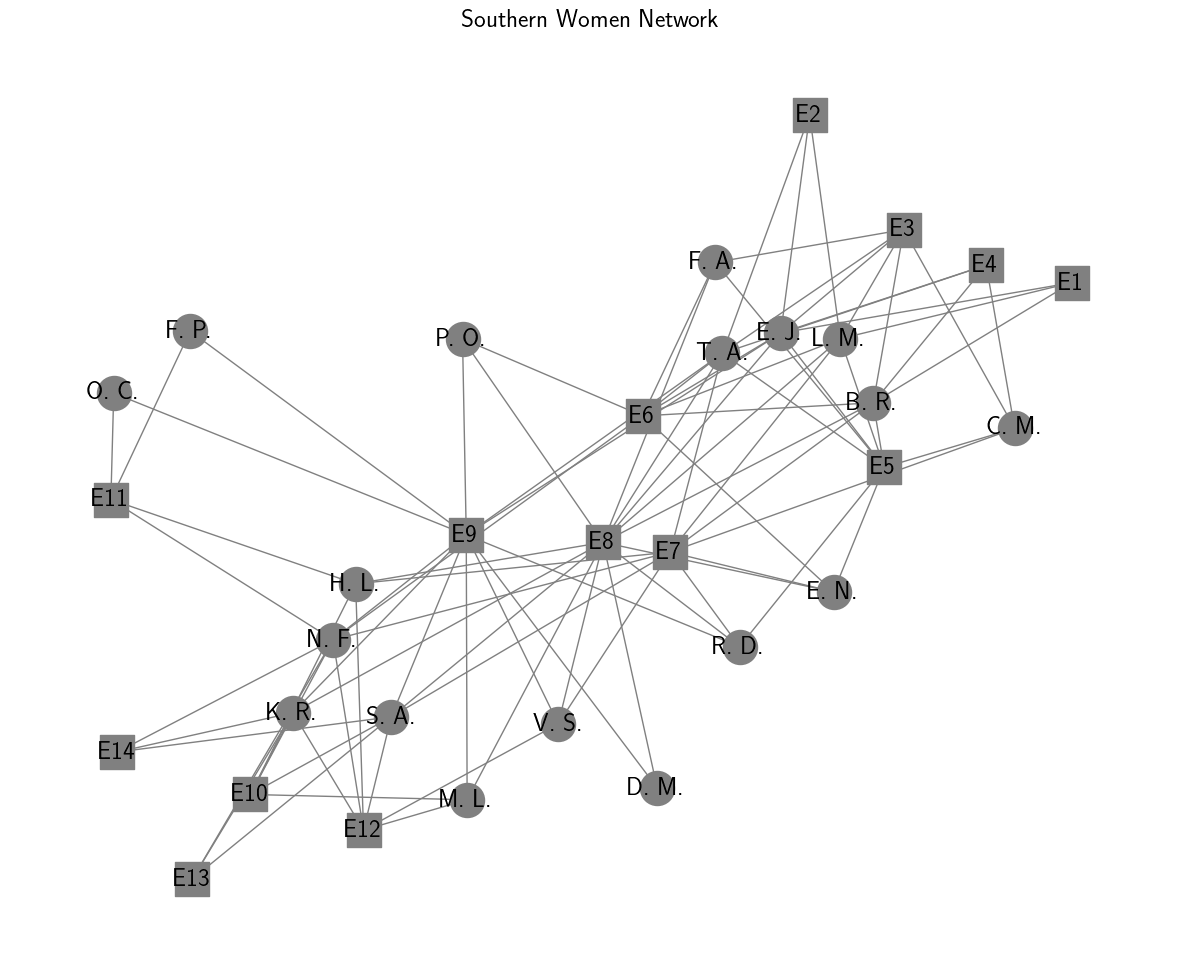

In [60]:
import networkx as nx # useful python package for networks and graphs
import matplotlib.pyplot as plt
#plt.rcParams['text.usetex'] = True  # Active le rendu LaTeX
G = nx.davis_southern_women_graph() # Get the Southern Women network
# Recovery of the women and events from node's graph
women = [n for n, d in G.nodes(data=True) if d['bipartite'] == 0]
events = [n for n, d in G.nodes(data=True) if d['bipartite'] == 1]

# Network Display
pos = nx.spring_layout(G, seed=12)


node_list = list(G.nodes())
plt.figure(figsize=(15,12))

nx.draw_networkx_nodes(G, pos,
                       nodelist=women,
                       node_shape='o',
                       node_color='gray',
                       node_size=600)

nx.draw_networkx_nodes(G, pos,
                       nodelist=events,
                       node_color="gray",
                       node_shape='s',
                       node_size=600)


nx.draw_networkx_edges(G, pos, edge_color='gray')
# labels
labels = {}
for n in G.nodes():
    if n in women:
        parts = n.split()
        initials = '. '.join(p[0] for p in parts) + '.'
        labels[n] = initials
    else:
        labels[n] = n

nx.draw_networkx_labels(G, pos, labels=labels, font_size=18)

plt.title("Southern Women Network",fontsize=18)
plt.axis('off')
plt.show()


## Community detection via OtrisymNMF
We detect 5 communities using OtrisymNMF with its method FROST.
Our method gives :
- v is a vector of length n (with n being the number of nodes) indicating the community index for each node.
- w is a vector of length n indicating the  importance of a node within its community.
- S describes interactions between the r communities.


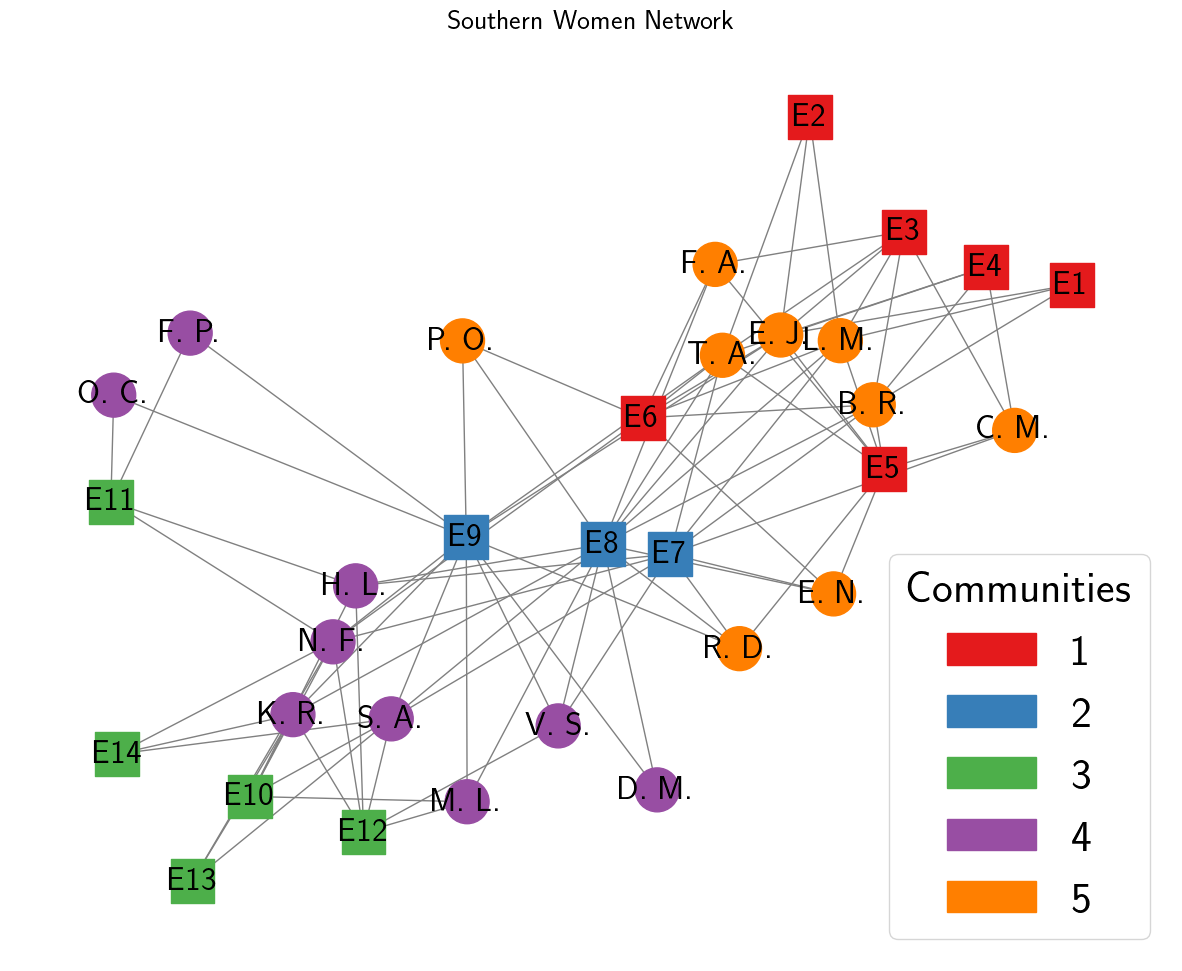

In [61]:
import matplotlib.patches as mpatches
import random
import numpy as np
import otrisymNMF

random.seed(45)
np.random.seed(19)
X = nx.adjacency_matrix(G) #adjacency matrix
r=5
w, v, S, error,_ = otrisymNMF.frost(X,r,numTrials=10,verbosity=0)

# permutation of community indexes for visualisation
perm = [0,1,4,3,2]
Sp = S[perm, :][:, perm]
vp= np.array([4 if x == 2 else 2 if x == 4 else x for x in v])

# Graph Display with labels v
pos = nx.spring_layout(G, seed=12)
plt.rcParams['text.usetex'] = True  # Active le rendu LaTeX
colors = ['#E41A1C',  # rouge vif
          '#377EB8',  # bleu soutenu
          '#4DAF4A',  # vert modéré
          '#984EA3',  # violet foncé
          '#FF7F00']  # orange vif


node_list = list(G.nodes())
node_colors = [colors[vp[i]] for i in range(len(node_list))]
plt.figure(figsize=(15,12))

nx.draw_networkx_nodes(G, pos,
                       nodelist=women,
                       node_color=[node_colors[node_list.index(n)] for n in women],
                       node_shape='o',
                       node_size=1000)

nx.draw_networkx_nodes(G, pos,
                       nodelist=events,
                       node_color=[node_colors[node_list.index(n)] for n in events],
                       node_shape='s',
                       node_size=1000)


nx.draw_networkx_edges(G, pos, edge_color='gray')


nx.draw_networkx_labels(G, pos, labels=labels, font_size=24)
legend_patches = []
for i in range(5):  # 5 communities
    patch = mpatches.Patch(color=colors[i], label=f'{i+1}')
    legend_patches.append(patch)

plt.legend(handles=legend_patches, loc='lower right', fontsize=32, title_fontsize=32, title="Communities")
plt.title("Southern Women Network",fontsize=20)
plt.axis('off')
plt.show()

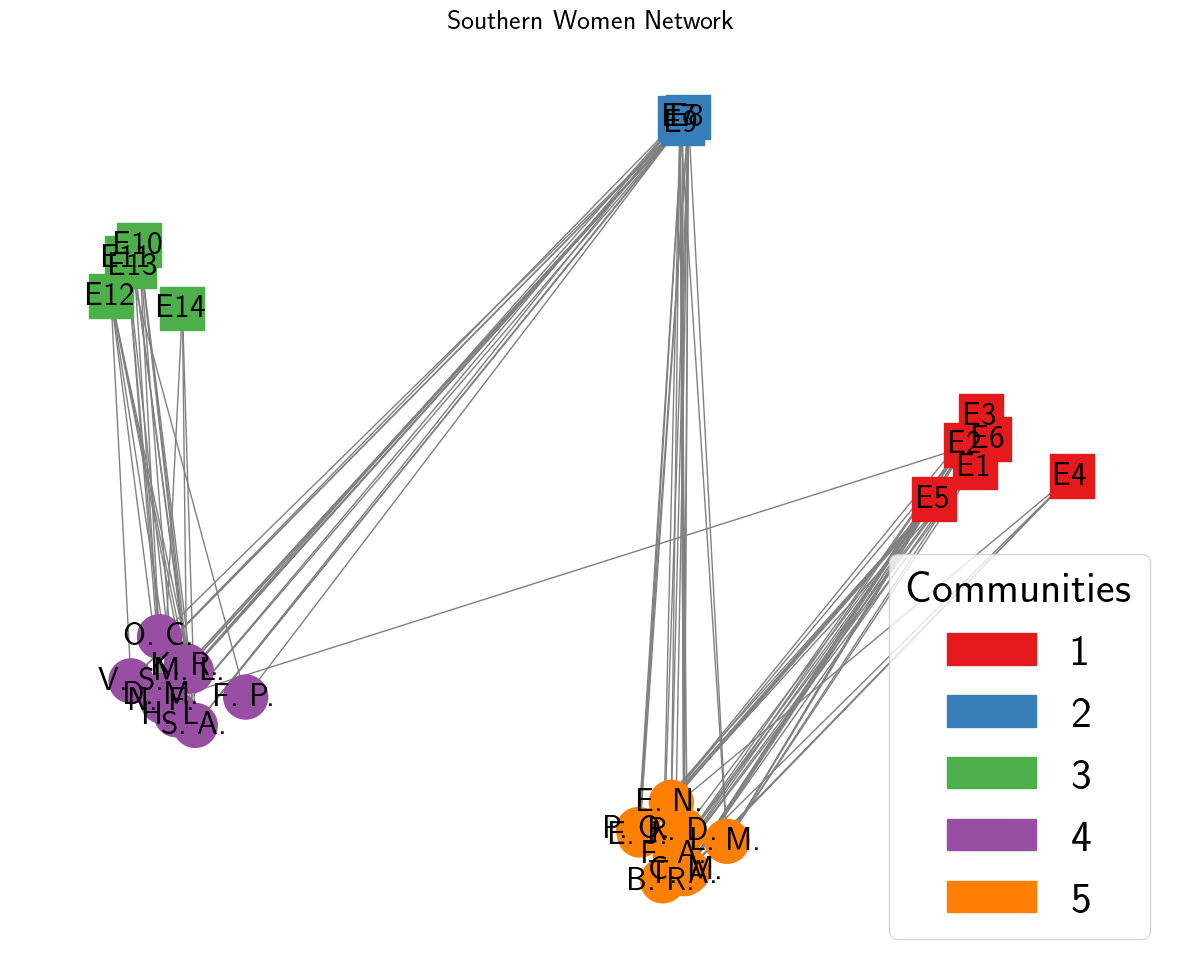

In [62]:
plt.figure(figsize=(15,12))
# --- Générer une position clusterisée ---
# Nombre de communautés
num_communities = max(vp) + 1

# Créer un centre pour chaque communauté
theta = np.linspace(0, 2*np.pi, num_communities, endpoint=False)
radius = 20  # distance entre les centres
community_centers = {i: np.array([radius*np.cos(t), radius*np.sin(t)]) for i,t in enumerate(theta)}

# Position finale des nœuds
pos = {}
for i, node in enumerate(node_list):
    comm = vp[i]
    # placer les nœuds aléatoirement autour du centre de leur communauté
    offset = np.random.randn(2) * 1.5  # dispersion autour du centre
    pos[node] = community_centers[comm] + offset

nx.draw_networkx_nodes(G, pos,
                       nodelist=women,
                       node_color=[node_colors[node_list.index(n)] for n in women],
                       node_shape='o',
                       node_size=1000)

nx.draw_networkx_nodes(G, pos,
                       nodelist=events,
                       node_color=[node_colors[node_list.index(n)] for n in events],
                       node_shape='s',
                       node_size=1000)


nx.draw_networkx_edges(G, pos, edge_color='gray')


nx.draw_networkx_labels(G, pos, labels=labels, font_size=24)
legend_patches = []
for i in range(5):  # 5 communities
    patch = mpatches.Patch(color=colors[i], label=f'{i+1}')
    legend_patches.append(patch)

plt.legend(handles=legend_patches, loc='lower right', fontsize=32, title_fontsize=32, title="Communities")
plt.title("Southern Women Network",fontsize=20)
plt.axis('off')
plt.show()

The five communities identified by OtrisymNMF in the Southern Women network, with women (circles) and events (squares) clearly separated, and each community represented by a distinct color

## Visualization of community interactions via the matrix S

Community: 1: ['E1', 'E2', 'E3', 'E4', 'E5', 'E6']
Community: 2: ['E7', 'E8', 'E9']
Community: 3: ['E10', 'E11', 'E12', 'E13', 'E14']
Community: 4: ['Verne Sanderson', 'Myra Liddel', 'Katherina Rogers', 'Sylvia Avondale', 'Nora Fayette', 'Helen Lloyd', 'Dorothy Murchison', 'Olivia Carleton', 'Flora Price']
Community: 5: ['Evelyn Jefferson', 'Laura Mandeville', 'Theresa Anderson', 'Brenda Rogers', 'Charlotte McDowd', 'Frances Anderson', 'Eleanor Nye', 'Pearl Oglethorpe', 'Ruth DeSand']


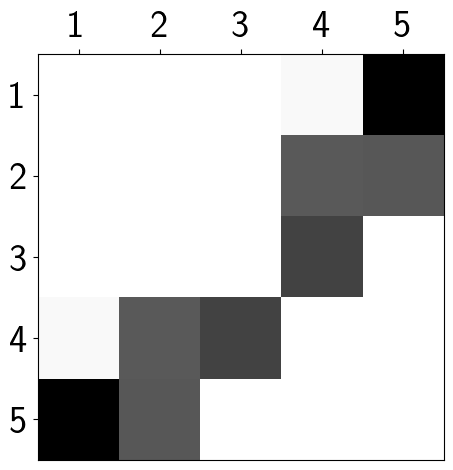

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [63]:
import numpy as np
# Print the communities
for i in range(max(v)+1):
    index=np.where(vp == i)[0]
    print(f"Community: {i+1}: {[list(G.nodes())[j] for j in index] }")
# Display of S with a heatmap
plt.imshow(Sp, cmap='Greys')
#cbar = plt.colorbar()
#cbar.ax.tick_params(labelsize=14)
plt.gca().xaxis.set_ticks_position('top')
plt.gca().xaxis.set_label_position('top')
labelscom = np.arange(1, S.shape[0] + 1)
plt.xticks(fontsize=28,ticks=np.arange(S.shape[1]), labels=labelscom)
plt.yticks(fontsize=28,ticks=np.arange(S.shape[0]), labels=labelscom)
#plt.title("Heatmap of matrix S\nInteraction between the communities", pad=30)
#plt.xlabel('Community j',fontsize=28)
#plt.ylabel('Community i',fontsize=28)
plt.tight_layout()
plt.show()

# Display of W with a heatmap
W=np.zeros((len(v),r))
for i in range(len(v)):
    W[i,vp[i]]=w[i]

Xrec=W@S@W.T
print(max(max(Xrec)))
selected=[0,20,26,3,10,31,16]
W=W[:,perm]
plt.imshow(W[selected,:], cmap='Greys')
#cbar = plt.colorbar()
#cbar.ax.tick_params(labelsize=14)
plt.gca().xaxis.set_ticks_position('top')
plt.gca().xaxis.set_label_position('top')
labelscom = np.arange(1, W.shape[1] + 1)
plt.xticks(fontsize=28,ticks=np.arange(W.shape[1]), labels=labelscom)
plt.yticks(fontsize=20,ticks=np.arange(len(selected)), labels=np.array(list(labels.values()))[selected])
#plt.title("Heatmap of matrix S\nInteraction between the communities", pad=30)
#plt.xlabel('Community j',fontsize=28)
#plt.ylabel('Community i',fontsize=28)
plt.tight_layout()
plt.show()

#Display of A with a heatmap
X_sel=X[selected][:, selected].toarray()
plt.imshow(X_sel, cmap='Greys')
#cbar = plt.colorbar()
#cbar.ax.tick_params(labelsize=14)
plt.gca().xaxis.set_ticks_position('top')
plt.gca().xaxis.set_label_position('top')
labelscom = np.arange(1, W.shape[1] + 1)
plt.xticks(fontsize=20,ticks=np.arange(len(selected)), labels=np.array(list(labels.values()))[selected])
plt.yticks(fontsize=20,ticks=np.arange(len(selected)), labels=np.array(list(labels.values()))[selected])
#plt.title("Heatmap of matrix S\nInteraction between the communities", pad=30)
#plt.xlabel('Community j',fontsize=28)
#plt.ylabel('Community i',fontsize=28)
plt.tight_layout()
plt.show()




The matrix S provides a clearer interpretation of the community structure. The matrix S, clearly illustrating the bipartition and the interactions between communities.


## Community detection via DCBM (initialization SVCA)

In [ ]:
import pysbm
from dcbm import dcbm
from sklearn.metrics import normalized_mutual_info_score as nmi

DCBM_partition=dcbm(G,5,pysbm.DegreeCorrectedUnnormalizedLogLikelyhood,pysbm.EMInference, numTrials=5,verbosity=1,init_method="SVCA")
print(f" Normalized mutual information between the partition found by DCBM and the one found by OtrisymNMF :{nmi(DCBM_partition,v)}")



The partition found by DCBM is the same as the one obtained by OtrisymNMF.

Spectral methods

In [ ]:
from scipy.sparse.linalg import eigsh
from sklearn.cluster import KMeans
X = X.astype(np.float64)
L, U = eigsh(X, k=r, which='LM')
X2=U@np.diag(np.sqrt(np.abs(L)))
Y=np.zeros((32,r))
for i in range(32):
    Y[i,:]=X2[i,:]/np.linalg.norm(X2[i,:])
labels_spec = KMeans(n_clusters=r, random_state=42).fit_predict(Y)
print(f" Normalized mutual information between the partition found by spectral and the one found by OtrisymNMF :{nmi(DCBM_partition,labels_spec)}")

In [ ]:
# Graph Display with labels v
pos = nx.spring_layout(G, seed=12)
plt.rcParams['text.usetex'] = True  # Active le rendu LaTeX
colors = ['#E41A1C',  # rouge vif
          '#377EB8',  # bleu soutenu
          '#4DAF4A',  # vert modéré
          '#984EA3',  # violet foncé
          '#FF7F00']  # orange vif


node_list = list(G.nodes())
node_colors = [colors[labels_spec[i]] for i in range(len(node_list))]
plt.figure(figsize=(15,12))

nx.draw_networkx_nodes(G, pos,
                       nodelist=women,
                       node_color=[node_colors[node_list.index(n)] for n in women],
                       node_shape='o',
                       node_size=1000)

nx.draw_networkx_nodes(G, pos,
                       nodelist=events,
                       node_color=[node_colors[node_list.index(n)] for n in events],
                       node_shape='s',
                       node_size=1000)


nx.draw_networkx_edges(G, pos, edge_color='gray')


nx.draw_networkx_labels(G, pos, labels=labels, font_size=24)
legend_patches = []
for i in range(5):  # 5 communities
    patch = mpatches.Patch(color=colors[i], label=f'{i+1}')
    legend_patches.append(patch)

plt.legend(handles=legend_patches, loc='lower right', fontsize=32, title_fontsize=32, title="Communities")
plt.title("Southern Women Network",fontsize=20)
plt.axis('off')
plt.show()